In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, chi2

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

from sklearn.model_selection import GridSearchCV

import pickle

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print(df.shape)

print(df.info())

print(df.isnull().sum())

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

In [4]:
df.drop('customerID', axis=1, inplace=True)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

print(df.isnull().sum())

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


/tmp/ipykernel_6299/1885425545.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [5]:
print(df.duplicated().sum())

22


In [6]:
df.drop_duplicates(inplace=True)

print(df.duplicated().sum())

0


In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column])

print(df.head())

   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   

   MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
0              1                0               0             2   
1              0                0               2             0   
2              0                0               2             2   
3              1                0               2             0   
4              0                1               0             0   

   DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  \
0                 0            0            0                0         0   
1                 

In [27]:
from sklearn.feature_selection import SelectKBest, chi2

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

selector = SelectKBest(score_func=chi2, k=10)
X_selected = selector.fit_transform(X, y)

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

In [57]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [43]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [61]:
from sklearn.metrics import accuracy_score

results = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "Decision Tree": accuracy_score(y_test, y_pred_dt),
    "Random Forest": accuracy_score(y_test, y_pred_rf)
}

best_model = max(results, key=results.get)

print("Model Results:")
for name, score in results.items():
    print(name, ":", score)

print("\nBest Model is:", best_model)

Model Results:
Logistic Regression : 0.7957295373665481
Decision Tree : 0.7359430604982207
Random Forest : 0.7822064056939502

Best Model is: Logistic Regression


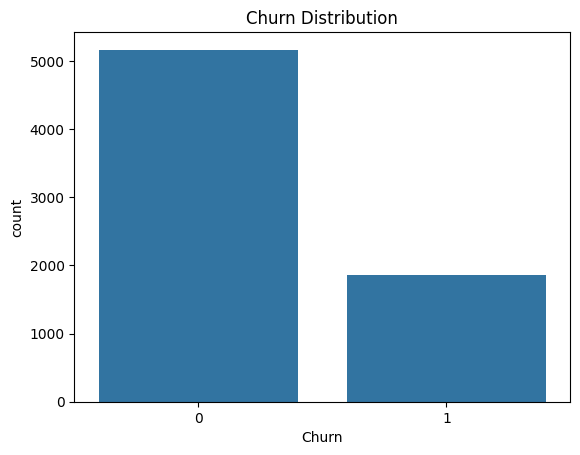

In [29]:
sns.countplot(x='Churn', data=df)

plt.title('Churn Distribution')

plt.show()

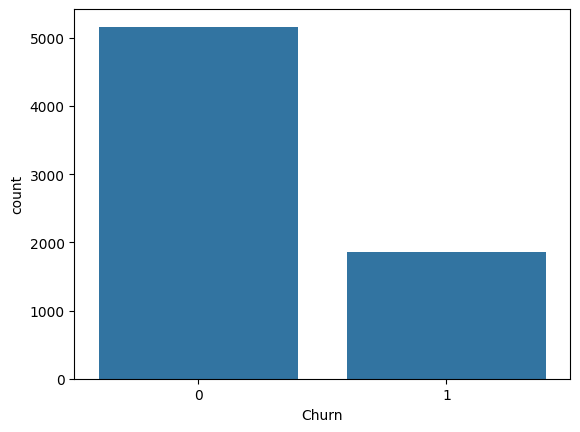

In [30]:
sns.countplot(x='Churn', data=df)
plt.show()

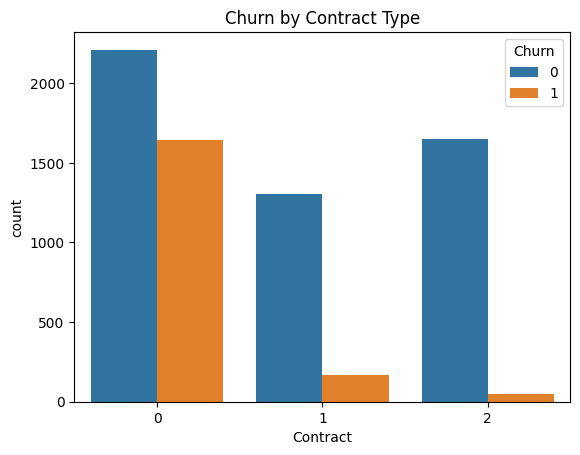

In [31]:
sns.countplot(x='Contract', hue='Churn', data=df)

plt.title('Churn by Contract Type')

plt.show()

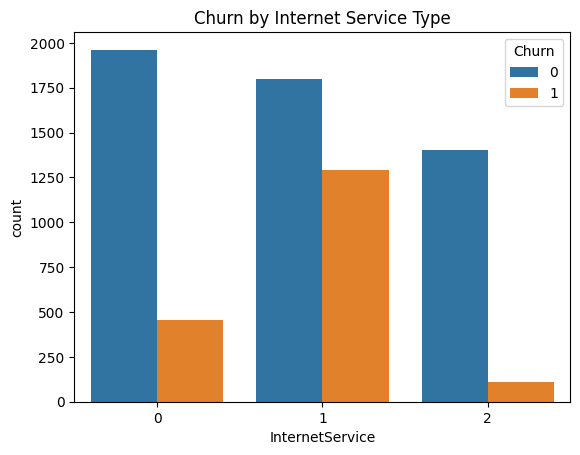

In [32]:
sns.countplot(x='InternetService', hue='Churn', data=df)

plt.title('Churn by Internet Service Type')
plt.show()

In [33]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
le = LabelEncoder()

for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = le.fit_transform(df_encoded[col])

In [34]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [36]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [37]:
from sklearn.metrics import accuracy_score, confusion_matrix

y_pred = model.predict(X_test)

print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

0.7957295373665481
[[933 120]
 [167 185]]


In [38]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.coef_[0]
})

importance = importance.sort_values(by='Importance', ascending=False)
print(importance)

             Feature  Importance
15  PaperlessBilling    0.288657
1      SeniorCitizen    0.268171
7    InternetService    0.186881
6      MultipleLines    0.089062
16     PaymentMethod    0.049475
2            Partner    0.049278
13   StreamingMovies    0.042998
17    MonthlyCharges    0.022354
12       StreamingTV    0.014885
18      TotalCharges    0.000283
0             gender   -0.019800
4             tenure   -0.056485
10  DeviceProtection   -0.087328
9       OnlineBackup   -0.153367
3         Dependents   -0.220429
8     OnlineSecurity   -0.292205
11       TechSupport   -0.300993
14          Contract   -0.669261
5       PhoneService   -0.994325


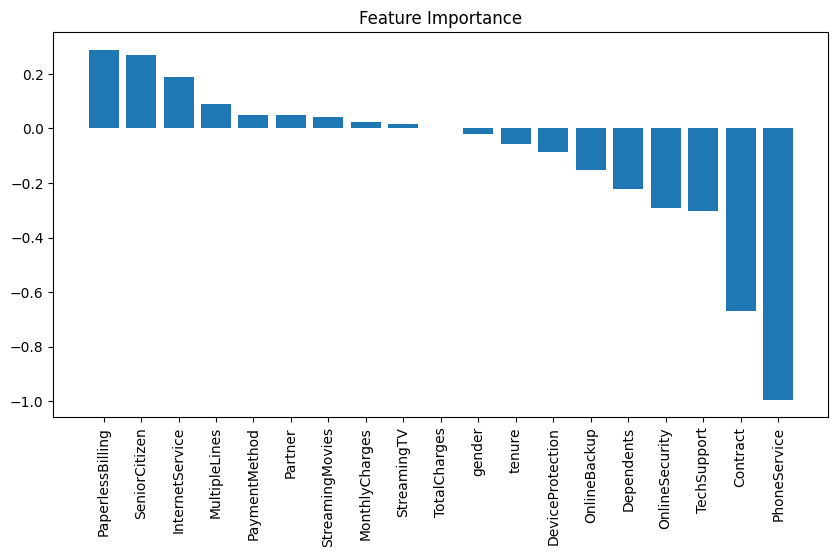

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(importance['Feature'], importance['Importance'])
plt.xticks(rotation=90)
plt.title('Feature Importance')
plt.show()

In [40]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1053
           1       0.61      0.53      0.56       352

    accuracy                           0.80      1405
   macro avg       0.73      0.71      0.71      1405
weighted avg       0.79      0.80      0.79      1405



After training the model, we analyzed feature importance to understand which factors most influence customer churn. This helps the company identify the main reasons why customers leave.

In [47]:
import joblib

joblib.dump(model, "model.pkl")

['model.pkl']

In [63]:
joblib.dump(le, "encoder.pkl")

['encoder.pkl']

In [64]:
code = """
import joblib
import numpy as np

model = joblib.load("model.pkl")

input_data = np.array([[1, 0, 0, 1]])

prediction = model.predict(input_data)

print("Prediction:", prediction)
"""

with open("app.py", "w") as f:
    f.write(code)

In [65]:
code = """
import joblib
import numpy as np

model = joblib.load("model.pkl")

input_data = np.array([[1, 0, 0, 1]])

prediction = model.predict(input_data)

print("Prediction:", prediction)
"""

with open("app.py", "w") as f:
    f.write(code)

In [66]:
from google.colab import files
files.download("app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [67]:
import joblib

joblib.dump(lr, "model.pkl")

['model.pkl']

In [68]:
from google.colab import files
files.download("model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>